In [15]:
import os
import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [16]:
from google.colab import drive
drive.mount('/content/drive')

PASSION_ROOT = "/content/drive/MyDrive/PASSION_MICCAI_2024"
IMG_DIR      = os.path.join(PASSION_ROOT, "images")
CSV_PATH     = os.path.join(PASSION_ROOT, "label.csv")

df = pd.read_csv(CSV_PATH)
print(f"Metadata rows: {len(df)}")
print(df['conditions_PASSION'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata rows: 1653
conditions_PASSION
Fungal     579
Scabies    471
Eczema     414
Others     189
Name: count, dtype: int64


In [17]:
PASSION_CLASSES = {
    'Fungal':  0,
    'Scabies': 1,
    'Eczema':  2,
    'Others':  3,
}

CLASS_NAMES = ['Fungal', 'Scabies', 'Eczema', 'Others']

class PASSIONDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []

        subject_lookup = {
            row['subject_id']: {
                'label':       PASSION_CLASSES[row['conditions_PASSION']],
                'fitzpatrick': row['fitzpatrick']
            }
            for _, row in df.iterrows()
        }

        for filename in os.listdir(img_dir):
            if not filename.endswith(('.jpg', '.jpeg', '.png')):
                continue
            if '(' in filename:
                continue

            subject_id = filename.rsplit('_', 1)[0]

            if subject_id not in subject_lookup:
                continue

            info = subject_lookup[subject_id]
            self.samples.append((
                os.path.join(img_dir, filename),
                info['label'],
                info['fitzpatrick']
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, fitzpatrick = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, fitzpatrick

In [18]:
from sklearn.model_selection import train_test_split

# Get unique patient IDs
patient_ids = df['subject_id'].unique()
print(f"Total unique patients: {len(patient_ids)}")

# Split patients 80/10/10
train_ids, temp_ids = train_test_split(patient_ids, test_size=0.20, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,    test_size=0.50, random_state=42)

print(f"Train patients: {len(train_ids)}")
print(f"Val patients:   {len(val_ids)}")
print(f"Test patients:  {len(test_ids)}")

# Create three dataframes — one per split
train_df = df[df['subject_id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain rows: {len(train_df)}")
print(f"Val rows:   {len(val_df)}")
print(f"Test rows:  {len(test_df)}")

Total unique patients: 1653
Train patients: 1322
Val patients:   165
Test patients:  166

Train rows: 1322
Val rows:   165
Test rows:  166


In [19]:
from torchvision import transforms

# Train transform
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # resize slightly larger
    transforms.RandomCrop(224),           # then random crop to 224
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),      # add vertical flip
    transforms.RandomRotation(20),        # increase rotation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/test transform — no augmentation, just resize and normalise
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = PASSIONDataset(train_df, IMG_DIR, transform=train_transform)
val_dataset   = PASSIONDataset(val_df,IMG_DIR, transform=val_transform)
test_dataset  = PASSIONDataset(test_df, IMG_DIR, transform=val_transform)

print(f"Train images: {len(train_dataset)}")
print(f"Val images:   {len(val_dataset)}")
print(f"Test images:  {len(test_dataset)}")

Train images: 3994
Val images:   459
Test images:  448


In [20]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True,num_workers=2)
val_loader =   DataLoader(val_dataset, batch_size=32,shuffle=False,num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32,shuffle=False,num_workers=2)

In [21]:
import torch.nn as nn

def build_e2_model(num_classes=4):
    weights = models.MobileNet_V3_Small_Weights.DEFAULT
    model   = models.mobilenet_v3_small(weights=weights)

    model.classifier[3] = nn.Linear(1024, num_classes)


    model.classifier[2] = nn.Dropout(p=0.4)
    return model

model_e2 = build_e2_model(num_classes=4).to(device)
print("E2 model built")
print(f"Classifier head: {model_e2.classifier[3]}")

E2 model built
Classifier head: Linear(in_features=1024, out_features=4, bias=True)


In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_e2.parameters(),
    lr=3e-4,              # slightly higher to start faster
    weight_decay=1e-4     # L2 regularisation — penalises large weights
)

# Reduce LR by half if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.2
)

print("Loss, optimiser, scheduler ready")

Loss, optimiser, scheduler ready


In [23]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels, _ in loader:   # _ ignores fitzpatrick during training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

    return total_loss / total, correct / total

In [24]:
NUM_EPOCHS    = 50
PATIENCE      = 7       # stop if val accuracy doesn't improve for 7 epochs
best_val_acc  = 0.0
best_model_path = 'e2_best_model.pth'
no_improve    = 0       # counter

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model_e2, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc = validate(
        model_e2, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_e2.state_dict(), best_model_path)
        no_improve = 0
        saved = "✓ saved"
    else:
        no_improve += 1
        saved = f"(no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest val accuracy: {best_val_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 01/50 | Train Loss: 1.0223 | Train Acc: 0.5566 | Val Loss: 1.0351 | Val Acc: 0.5664 ✓ saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 02/50 | Train Loss: 0.7864 | Train Acc: 0.6790 | Val Loss: 0.9551 | Val Acc: 0.6035 ✓ saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


...

Epoch 17/50 | Train Loss: 0.2154 | Train Acc: 0.9186 | Val Loss: 1.1002 | Val Acc: 0.6645 (no improve 5/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 18/50 | Train Loss: 0.1986 | Train Acc: 0.9316 | Val Loss: 1.1005 | Val Acc: 0.6623 (no improve 6/7)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch 19/50 | Train Loss: 0.2046 | Train Acc: 0.9276 | Val Loss: 1.1056 | Val Acc: 0.6623 (no improve 7/7)

Early stopping triggered at epoch 19

Best val accuracy: 0.6776


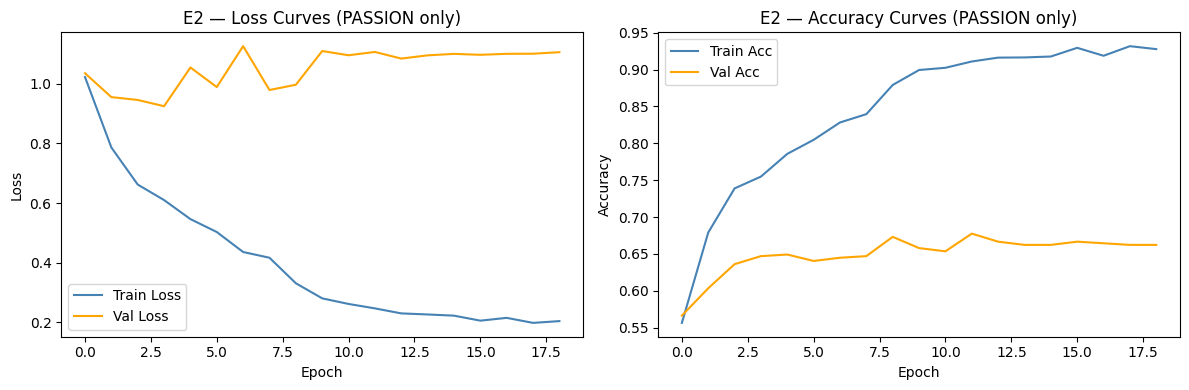

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='orange')
axes[0].set_title('E2 — Loss Curves (PASSION only)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='steelblue')
axes[1].plot(val_accs,   label='Val Acc',   color='orange')
axes[1].set_title('E2 — Accuracy Curves (PASSION only)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('e2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

E2 — MobileNetV3-Small trained on PASSION only
Best validation accuracy: 67.8%
Stopped at epoch: 19
Notes: Overfitting observed (train acc 93% vs val acc 68%)
       Consistent with limited dataset size (~3,900 training images)

In [26]:
# Load best model
model_e2.load_state_dict(torch.load('e2_best_model.pth'))


test_loss, test_acc = validate(model_e2, test_loader, criterion, device)
print(f"E2 Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E2 Test Accuracy: 0.7366


In [27]:
from collections import defaultdict

def evaluate_fitzpatrick(model, loader, device):
    model.eval()
    fitz_correct = defaultdict(int)
    fitz_total   = defaultdict(int)

    with torch.no_grad():
        for images, labels, fitzpatricks in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds   = outputs.argmax(dim=1)

            for pred, label, fitz in zip(preds.cpu(), labels.cpu(), fitzpatricks):
                fitz_total[fitz.item()]   += 1
                if pred == label:
                    fitz_correct[fitz.item()] += 1

    results = {
        fitz: fitz_correct[fitz] / fitz_total[fitz]
        for fitz in sorted(fitz_total)
        if fitz_total[fitz] > 0
    }
    return results

fitz_accs = evaluate_fitzpatrick(model_e2, test_loader, device)

print("E2 — Accuracy by Fitzpatrick type (test set):")
for fitz, acc in fitz_accs.items():
    bar = "█" * int(acc * 30)
    print(f"  Type {fitz}: {acc:.4f}  {bar}")

dark_accs = {k: v for k, v in fitz_accs.items() if k in [4, 5, 6]}
disparity = max(dark_accs.values()) - min(dark_accs.values())
print(f"\nDark skin tone accuracy (IV-VI): {dark_accs}")
print(f"Max disparity across IV-VI:      {disparity:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


E2 — Accuracy by Fitzpatrick type (test set):
  Type 3: 0.7190  █████████████████████
  Type 4: 0.7536  ██████████████████████
  Type 5: 0.7478  ██████████████████████
  Type 6: 0.7143  █████████████████████

Dark skin tone accuracy (IV-VI): {4: 0.7536231884057971, 5: 0.7478260869565218, 6: 0.7142857142857143}
Max disparity across IV-VI:      0.0393


In [28]:
import json

e2_results = {
    "experiment":           "E2",
    "model":                "MobileNetV3-Small",
    "pretrained_on":        "ImageNet",
    "trained_on":           "PASSION only",
    "evaluated_on":         "PASSION test set",
    "num_classes":          4,
    "best_val_accuracy":    0.6776,
    "test_accuracy":        round(test_acc, 4),
    "fitzpatrick_accuracies": {str(k): round(v, 4) for k, v in fitz_accs.items()},
    "dark_skin_disparity":  round(disparity, 4),
    "notes": "Overfitting observed — train acc ~93% vs val acc ~68%. "
             "Consistent with limited dataset size (~3,900 training images)."
}

with open('e2_results.json', 'w') as f:
    json.dump(e2_results, f, indent=2)

print(json.dumps(e2_results, indent=2))

{
  "experiment": "E2",
  "model": "MobileNetV3-Small",
  "pretrained_on": "ImageNet",
  "trained_on": "PASSION only",
  "evaluated_on": "PASSION test set",
  "num_classes": 4,
  "best_val_accuracy": 0.6776,
  "test_accuracy": 0.7366,
  "fitzpatrick_accuracies": {
    "3": 0.719,
    "4": 0.7536,
    "5": 0.7478,
    "6": 0.7143
  },
  "dark_skin_disparity": 0.0393,
  "notes": "Overfitting observed \u2014 train acc ~93% vs val acc ~68%. Consistent with limited dataset size (~3,900 training images)."
}
